In [95]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np



In [96]:
X,y = make_regression(n_samples = 100 , n_features =1 , n_informative=1 , n_targets = 1 , noise = 20  , random_state = 13 )

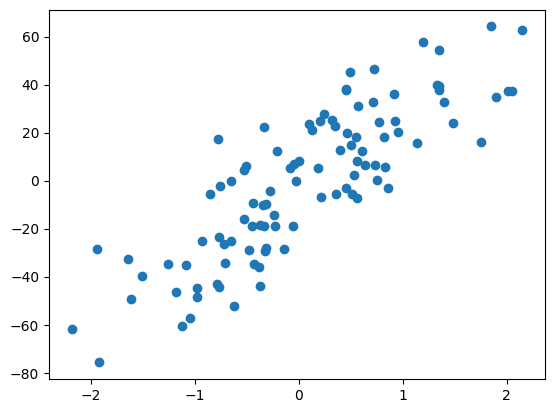

In [97]:
plt.scatter(X,y)

In [98]:
from sklearn.linear_model import LinearRegression


In [99]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [100]:
from sklearn.linear_model import Ridge

In [101]:
rr = Ridge(alpha = 10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [102]:
rr1 = Ridge(alpha = 100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


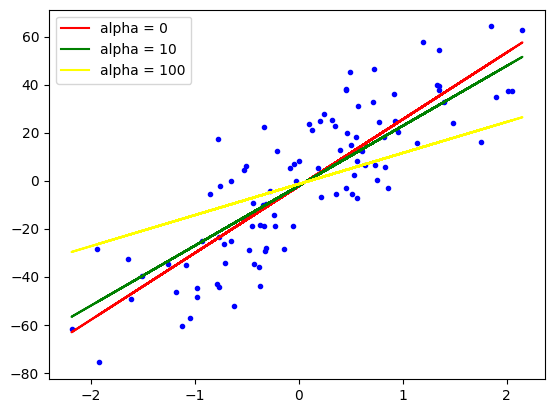

In [103]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X), color = 'red' , label = 'alpha = 0')
plt.plot(X,rr.predict(X), color = 'green' , label = 'alpha = 10')
plt.plot(X,rr1.predict(X), color = 'yellow' , label = 'alpha = 100')
plt.legend()

In [104]:
class myRidge:
  def __init__(self,alpha = 0.1) :
    self.alpha = alpha
    self.m = None
    self.b = None

  def fit(self,X_train,y_train):
    num = 0
    den = 0

    for i in range(X_train.shape[0]):
      num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
      den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))

    self.m = num/(den + self.alpha)
    self.b = y_train.mean() - (self.m * X_train.mean())
    print(self.m)
    print(self.b)

  def predict(X_test):

    pass

In [105]:
reg = myRidge(alpha = 10)
reg.fit(X,y)

[24.9546267]
[-2.126913]


#For nd data

In [106]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [107]:
X,y = load_diabetes(return_X_y = True)

In [108]:
from sklearn.model_selection import train_test_split

In [109]:
X_train,X_test , y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 4)

In [110]:
from sklearn.linear_model import Ridge

In [111]:
reg = Ridge(alpha = 0.1 , solver = 'cholesky')

In [112]:
reg.fit(X_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [113]:
y_pred = reg.predict(X_test)
r2_score(y_test , y_pred)

0.4693128853309805

In [114]:
class MyRidge :
  def __init__(self,alpha = 0.1) :
    self.alpha = alpha
    self.coef = None
    self.intercept_ = None

  def fit(self, X_train , y_train):
    X_train = np.insert(X_train , 0 , 1 , axis = 1 )
    I = np.identity(X_train.shape[1])
    result = np.linalg.inv(np.dot(X_train.T , X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
    self.intercept_ = result[0]
    self.coef_ = result[1:]

  def predict(self , X_test) :
    return np.dot(X_test , self.coef_) + self.intercept_

In [115]:
reg = MyRidge()
reg.fit(X_train , y_train)
y_pred = reg.predict(X_test)
r2_score(y_test , y_pred)

print(r2_score(y_test , y_pred))
print(reg.coef_)
print(reg.intercept_)

0.46921361559931885
[  44.04252774 -241.72019592  452.99153345  332.06044266  -76.32617866
  -68.54884462 -165.01664054  149.93980143  431.59483654   58.54419942]
150.84762720023167
